In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [21]:
# Load dataset
data = pd.read_csv("/content/GOOGL.csv")
data


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602
...,...,...,...,...,...,...,...
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700


In [22]:
# Use 'Close' price
prices = data['Close'].values.reshape(-1,1)


In [23]:
# Use 'Close' price
prices = data['Close'].values.reshape(-1,1)

In [24]:
# Normalize
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)


In [25]:
# Create sequences
X = []
y = []

for i in range(60, len(prices)):
    X.append(prices[i-60:i])
    y.append(prices[i])

X, y = np.array(X), np.array(y)


In [26]:
 #Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [27]:
# Model
model = Sequential([
    LSTM(50, input_shape=(60,1)),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.compile(optimizer='adam', loss='mse')


In [29]:
# Train
history = model.fit(X_train, y_train, epochs=5)


Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0016
Epoch 2/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 4.1608e-05
Epoch 3/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.7095e-05
Epoch 4/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 3.4006e-05
Epoch 5/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 3.2537e-05


In [30]:
# Predict
pred = model.predict(X_test)
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


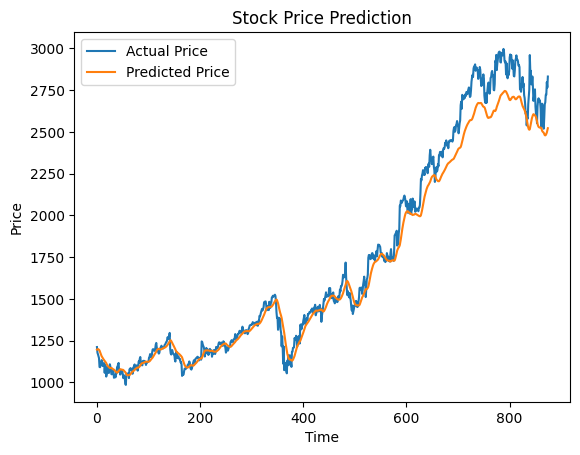

In [31]:
plt.plot(y_test_actual, label='Actual Price')
plt.plot(pred, label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [32]:
# Step 13: Evaluation

rmse = np.sqrt(mean_squared_error(y_test_actual, pred))
mae = mean_absolute_error(y_test_actual, pred)

print("RMSE:", rmse)
print("MAE:", mae)


RMSE: 106.66174016359395
MAE: 75.22987945536607
